## The BlueBike - Winter Bottleneck Pressure Index Analysis

In [3]:
import pandas as pd
import numpy as np

from analyze import (
analyze_hourly_imbalance,
plot_hourly_imbalance,
plot_hourly_severe,
analyze_weekday_imbalance,
plot_weekday_imbalance,
plot_weekday_severe,
analyze_station_imbalance,
plot_station_imbalance_distribution,
prepare_station_map_data,
plot_station_pressure_map,
plot_station_severe_imbalance,
plot_above_average_severe_map)

In [7]:
final_df = pd.read_csv("../data/final_data.csv")

final_df["pressure_index"] = pd.to_numeric(final_df["pressure_index"], errors="coerce")
final_df = final_df.dropna(subset=["pressure_index"])

print(final_df.shape)
print(final_df.columns.tolist())
final_df.head()

(180781, 17)
['station_id', 'hour', 'arrivals', 'departures', 'net_flow', 'lat', 'lon', 'municipality', 'total_docks', 'pressure_index', 'temperature_2m', 'precipitation', 'snowfall', 'wind_speed_10m', 'cloud_cover', 'hour_of_day', 'day_of_week']


,station_id,hour,arrivals,departures,net_flow,lat,lon,municipality,total_docks,pressure_index,temperature_2m,precipitation,snowfall,wind_speed_10m,cloud_cover,hour_of_day,day_of_week
0,A32000,2025-11-01 01:00:00,0.0,1.0,-1.0,42.353391,-71.044571,Boston,15.0,-0.066667,10.542999,0.0,0.0,24.823036,58.0,1,Saturday
1,A32000,2025-11-01 07:00:00,1.0,0.0,1.0,42.353391,-71.044571,Boston,15.0,0.066667,7.743000,0.0,0.0,26.109928,90.0,7,Saturday
2,A32000,2025-11-01 12:00:00,0.0,2.0,-2.0,42.353391,-71.044571,Boston,15.0,-0.133333,8.143000,0.0,0.0,21.996117,36.0,12,Saturday
3,A32000,2025-11-01 13:00:00,3.0,0.0,3.0,42.353391,-71.044571,Boston,15.0,0.200000,9.092999,0.0,0.0,21.589495,72.0,13,Saturday
4,A32000,2025-11-01 14:00:00,2.0,3.0,-1.0,42.353391,-71.044571,Boston,15.0,-0.066667,9.943000,0.0,0.0,22.442324,16.0,14,Saturday


### Section 1 - Hour of Day x Pressure Index Relationship
Here, data indicates which hours during the day has the highest pressure index as well as the % of stations that has pressure index above 0.2. This is to examine the peak hours in a day, setting the foundation for weather analysis.

In [8]:
hourly_imbalance = analyze_hourly_imbalance(final_df, severe_threshold=0.2)

hourly_imbalance.head()

,hour_of_day,mean_abs_pressure,severe_percent
0,0,0.070686,2.989324
1,1,0.072058,3.517588
2,2,0.067891,2.231147
3,3,0.061321,0.751880
4,4,0.057882,0.345722


#### Chart 1.1 - Mean Imbalance by Hour
As shown in the graph, several hours shows high percentage of sever imbalanced stations count. The hours are:
- 7AM - 9AM
- 3PM - 7PM

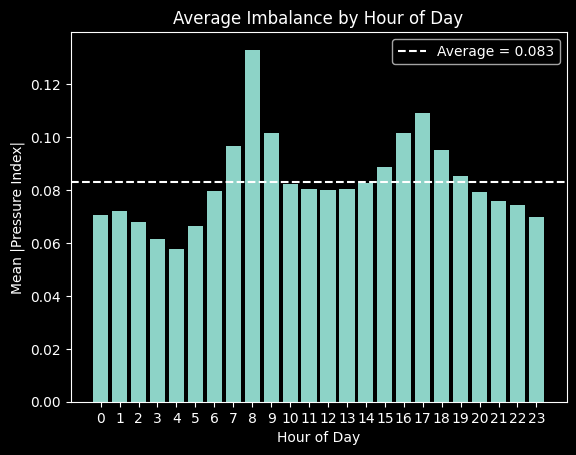

In [29]:
plot_hourly_imbalance(hourly_imbalance, result_dir="../results", notebook_plot=True)

#### Chart 1.2 - Severe imbalance Frequency by Hour Plot
The peak imbalance time of the day is at 8AM, with 5-6PM following as the second peak.
As shown in the graph, there are several hours that have severe imbalance. The hours are:
- 7AM - 9AM
- 3PM - 7PM

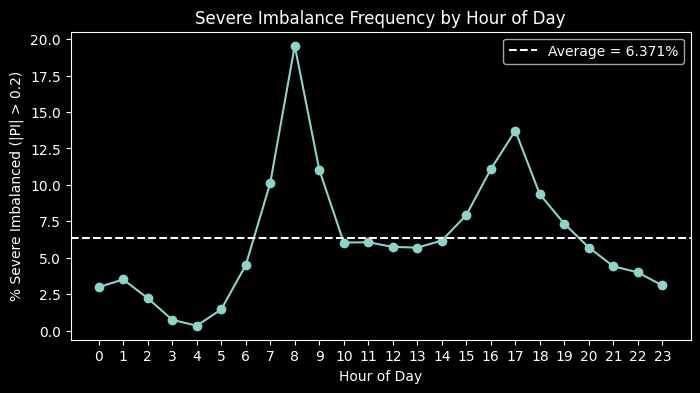

In [30]:
plot_hourly_severe(hourly_imbalance, result_dir="../esults", notebook_plot=True)

### Section 1 Insight
The result are highly correlated with the average absolute pressure index and the % of the imbalanced station during these two period, thereby identifying these two period as the peak period.

### Section 2 - Weekday Relationship with Pressure Index
Here, data indicates which day during the week has the highest pressure index as well as the % of stations that has pressure index above 0.2. This is to examine the peak day in a week, setting the foundation for weather analysis.

In [14]:
weekday_imbalance = analyze_weekday_imbalance(final_df, severe_threshold=0.2)
weekday_imbalance

,day_of_week,mean_abs_pressure,severe_percent
1,Monday,0.087763,7.445496
5,Tuesday,0.092207,8.957916
6,Wednesday,0.093766,9.346596
4,Thursday,0.091658,8.719836
0,Friday,0.087339,7.410917
2,Saturday,0.085217,7.059256
3,Sunday,0.081580,5.828177


#### Chart 2.1 - Mean Imbalance by Day

As shown in the graph, there are several day that have severe imbalance. The days are:
- Tuesday
- Wednesday
- Thursday

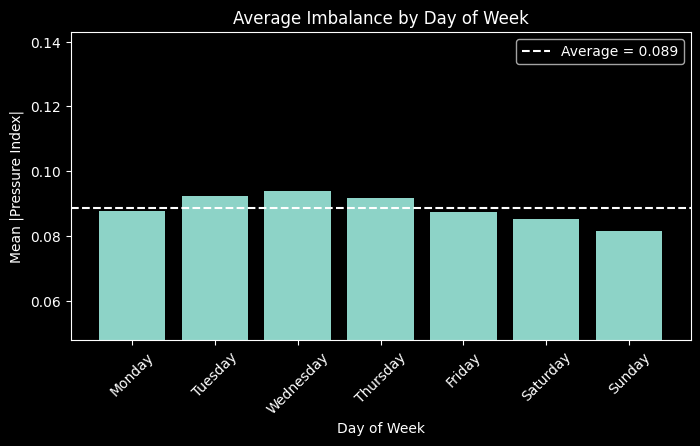

In [31]:
# Align weekday y-axis to the hourly plot to present more accurate showcase of data
y1_limits = (
    hourly_imbalance["mean_abs_pressure"].min() - 0.01,
    hourly_imbalance["mean_abs_pressure"].max() + 0.01,
)

plot_weekday_imbalance(
    weekday_imbalance,
    y_limits=y1_limits,
    result_dir="../results",
    notebook_plot=True,
)

#### Chart 2.2 - % of station that are severely imbalanced during the Week
As shown in the graph, several day shows high percentage of sever imbalanced stations count. The hours are:
- Tuesday
- Wednesday
- Thursday

The result are highly correlated with the average absolute pressure index and the % of the imbalanced station during these three days, thereby identifying these three days as the peak days.

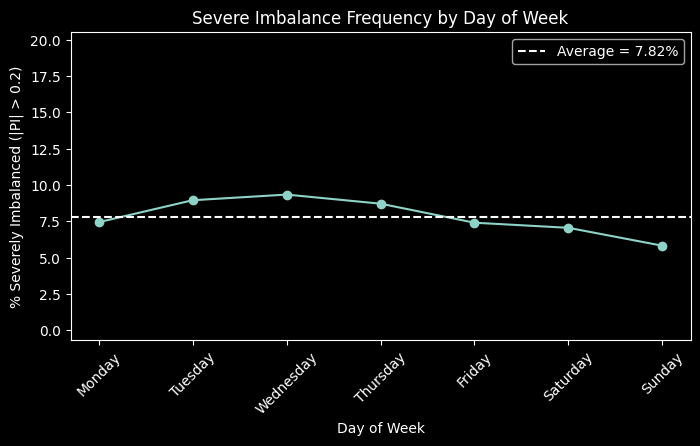

In [32]:
y2_limits = (
    hourly_imbalance["severe_percent"].min() - 1,
    hourly_imbalance["severe_percent"].max() + 1,
)

plot_weekday_severe(
    weekday_imbalance,
    y_limits=y2_limits,
    result_dir="../results",
    notebook_plot=True,
)

### Section 1 & 2 Conclusion:
1. There is **Strong Hourly Pattern** on station pressure. Peak imbalance occur during morning and evening commute hours.
3. There is **Weak Weekly Pattern**, where midweek (Tuesday - Thursday) shows slightly higher imbalance.

### Section 3 - Location and Pressure Index Relationship
Identifying which station face the highest imbalance as well as the % of stations that has pressure index above 0.2. This is to examine the peak station, setting the foundation for weather analysis.

In [19]:
station_imbalance = analyze_station_imbalance(final_df, severe_threshold=0.2)

print("Number of station:", len(station_imbalance))
station_imbalance.head()

Number of station: 582


,station_id,lat,lon,municipality,mean_abs_pressure,severe_percent
0,A32000,42.353391,-71.044571,Boston,0.125069,14.600551
1,A32001,42.353334,-71.137313,Boston,0.074277,4.545455
2,A32002,42.351692,-71.119035,Boston,0.145234,20.063191
3,A32003,42.350406,-71.108279,Boston,0.156624,23.062016
4,A32004,42.338629,-71.106500,Boston,0.243253,33.271719


In [20]:
avg_pressure = station_imbalance["mean_abs_pressure"].mean()
avg_severe = station_imbalance["severe_percent"].mean()

above_avg_pressure_count = (station_imbalance["mean_abs_pressure"] > avg_pressure).sum()
above_avg_severe_count = (station_imbalance["severe_percent"] > avg_severe).sum()

total_stations = len(station_imbalance)

print("Avg station mean imbalance:", avg_pressure)
print("Number of stations above average mean imbalance:", above_avg_pressure_count)
print("Above Average Imbalance Rate: " + str(round((above_avg_pressure_count/total_stations)*100)) + "%")

print(f"\nAvg severe imbalance frequency:", avg_severe)
print("Number of stations above average severe imbalance:", above_avg_severe_count)
print("Above Average Imbalance Rate: " + str(round((above_avg_severe_count/total_stations)*100)) + "%")

Avg station mean imbalance: 0.0829381113598953
Number of stations above average mean imbalance: 285
Above Average Imbalance Rate: 49%

Avg severe imbalance frequency: 5.571712225169628
Number of stations above average severe imbalance: 219
Above Average Imbalance Rate: 38%


### Section 3.1 - Station Imbalance
From the below result, it shows that most stations operate within a moderate range, with mean pressure index values concentrate between 0.05 - 0.1.

However, the distribution is not symmetric. Only 38% of stations exceed the average imbalance level, indicating that imbalance is concentrated on a small subset of stations.
Spatial visualization also show that these high imbalance stations are clustered in urban area and central regions of boston.

#### Chart 3.1.1 - Distribution of Station imbalance by Pressure Index

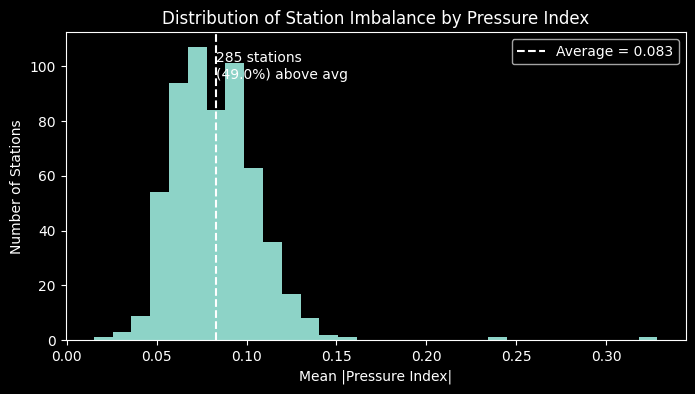

In [33]:
plot_station_imbalance_distribution(
    station_imbalance,
    result_dir="../results",
    notebook_plot=True,
)

#### Chart 3.1.2 - Station Imbalance Hotspots Map

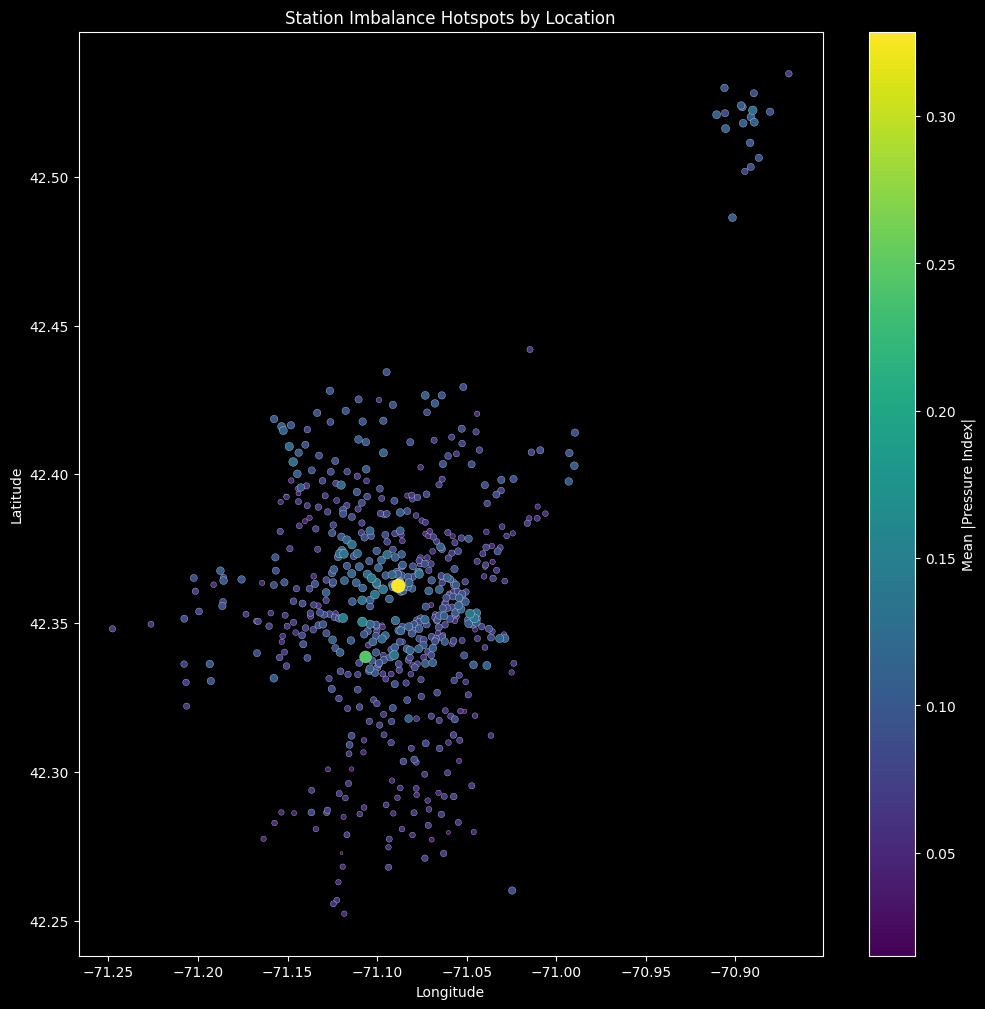

In [34]:
station_map_df = prepare_station_map_data(final_df, severe_threshold = 0.2)

plot_station_pressure_map(
    station_map_df,
    result_dir="../results",
    notebook_plot=True,
)

### Section 3.2 - Severe Frequency Distribution by Station
Severe imbalance frequency measures how often a station experiences extreme imbalance conditions. The average severe imbalance frequency across all stations is ~5.57%.

Severe imbalance is more widely distributed, with ~49% of stations exceed the average severe imbalance frequency. The distribution is again right skewed, with a few station reaches significant frequencies, with some reaching as high as 20%. This showcase that a few station repeatedly experience extreme imbalance.

#### Chart 3.2.1 - Distribution of Station Imbalance by Severe Imbalance

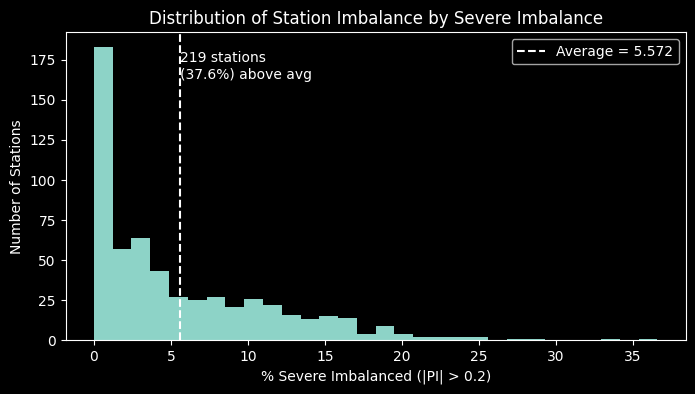

In [35]:
plot_station_severe_imbalance(
    station_imbalance,
    result_dir="../results",
    notebook_plot=True,
)

#### Chart 3.2.2 - Stations Above Average Severe Imbalance

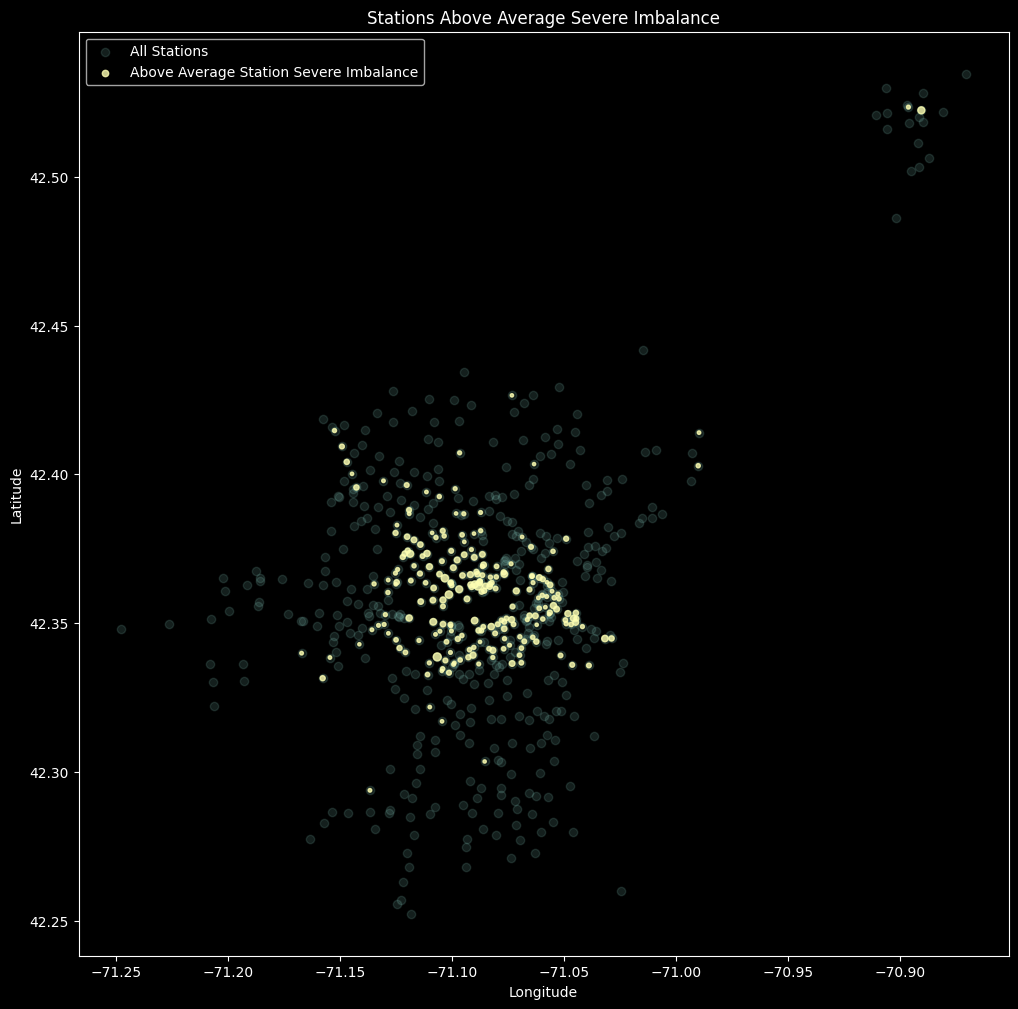

In [36]:
plot_above_average_severe_map(
    station_imbalance,
    result_dir="../results",
    notebook_plot=True,
)

### Section 3 Conclusion
The station imbalance and severe imbalance frequency reveals that imbalance is not random but concentrated in a specific locations, where a relatively small subset of stations consistently experiences higher than average imbalance. This showcase that location plays a significant role in future analysis on imbalance.

Stations in dense urban areas and key transit zones are more likely to experience both sustained and extreme imbalance.